In [9]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### 1) Graph Preparation:

In [10]:
# 1) Graph preparation: 
BASE_DIR = Path.cwd().parent
graph_path = BASE_DIR / "data" / "processed" / "world_trade_network_petrol_2024.gexf"
graph = nx.read_gexf(graph_path)

# 1.1) Since the classic theoretical models of random graphs assume non-directed and without weights graphs, 
# we shall modify our graph according to it as well, considering only its Giant Connected Component (GCC): 
graph = nx.Graph(graph)
gcc_nodes = max(nx.connected_components(graph), key=len)
graph = graph.subgraph(gcc_nodes).copy()

# 1.2) Extract the base metrics that will be used to compare our graph to the random ones: 
N = graph.number_of_nodes()
E = graph.number_of_edges()
k_avg = 2 * E / N  # Average degree.

# 1.3) Calculate the key metrics of our graph: 
C = nx.average_clustering(graph)
L = nx.average_shortest_path_length(graph)

### 2) Erdös-Rényi Model (ER):

In [11]:
# 2) Erdös-Rényi model (ER): 

# 2.1) Calculate the probability p of connecting two nodes in the model according to the 
# base metrics of our graph and using the formula c = p * (n-1), in which c is the average degree:
p_er = k_avg / (N - 1)

# 2.2) Create the graph and select only its GCC: 
G_er = nx.erdos_renyi_graph(n=N, p=p_er, seed=42)
gcc_er = max(nx.connected_components(G_er), key=len)
G_er = G_er.subgraph(gcc_er)

# 2.3) Calculate its key metrics: 
C_er = nx.average_clustering(G_er)
L_er = nx.average_shortest_path_length(G_er)

print("Erdős-Rényi Model:")
print(f"Clustering ER: {C_er:.4f} | Clustering Real Graph: {C:.4f}")
print(f"Path Length ER: {L_er:.4f} | Path Length Real Graph: {L:.4f}")

Erdős-Rényi Model:
Clustering ER: 0.0735 | Clustering Real Graph: 0.4181
Path Length ER: 2.3180 | Path Length Real Graph: 2.4758


### 3) Barabási-Albert model (BA):

In [12]:
# 3) Barabási-Albert model (BA):

# 3.1) Calculate the average number of edges per nodes in our graph, using it to 
# initialize the algorithm with that number as m: 
M = graph.number_of_edges()
M_INIT = int(round(M / N))

# 3.2) Create the graph: 
G_ba = nx.barabasi_albert_graph(N, M_INIT, seed=42)

# 3.3) Calculate its key metrics: 
C_ba = nx.average_clustering(G_ba)
L_ba = nx.average_shortest_path_length(G_ba)

print("Barabási-Albert Model:")
print(f"Clustering BA: {C_ba:.4f} | Clustering Real Graph: {C:.4f}")
print(f"Path Length BA: {L_ba:.4f} | Path Length Real Graph: {L:.4f}")

Barabási-Albert Model:
Clustering BA: 0.1464 | Clustering Real Graph: 0.4181
Path Length BA: 2.3033 | Path Length Real Graph: 2.4758


### 4) Watts-Strogatz model (WS):

In [13]:
# 4) Watts-Strogatz model (WS):

# 4.1) Calculate the k (number of connections of each node with its neighbours) 
# just by converting our average degree (k_avg) in an integer: 
k_ws = int(round(k_avg))

# 4.2) Create the graph, establishing the probability of reconnecting (making a 
# shortcut) by 0.1 (the default for simulating the "Small World"):
p_ws = 0.1
G_ws = nx.watts_strogatz_graph(n=N, k=k_ws, p=p_ws, seed=42)

# 4.3) Calculate its key metrics: 
C_ws = nx.average_clustering(G_ws)
L_ws = nx.average_shortest_path_length(G_ws)

print("Watts-Strogatz Model:")
print(f"Clustering WS: {C_ws:.4f} | Clustering Real Graph: {C:.4f}")
print(f"Path Length WS: {L_ws:.4f} | Path Length Real Graph: {L:.4f}")

Watts-Strogatz Model:
Clustering WS: 0.5095 | Clustering Real Graph: 0.4181
Path Length WS: 2.8558 | Path Length Real Graph: 2.4758


### 5) Analysis: 

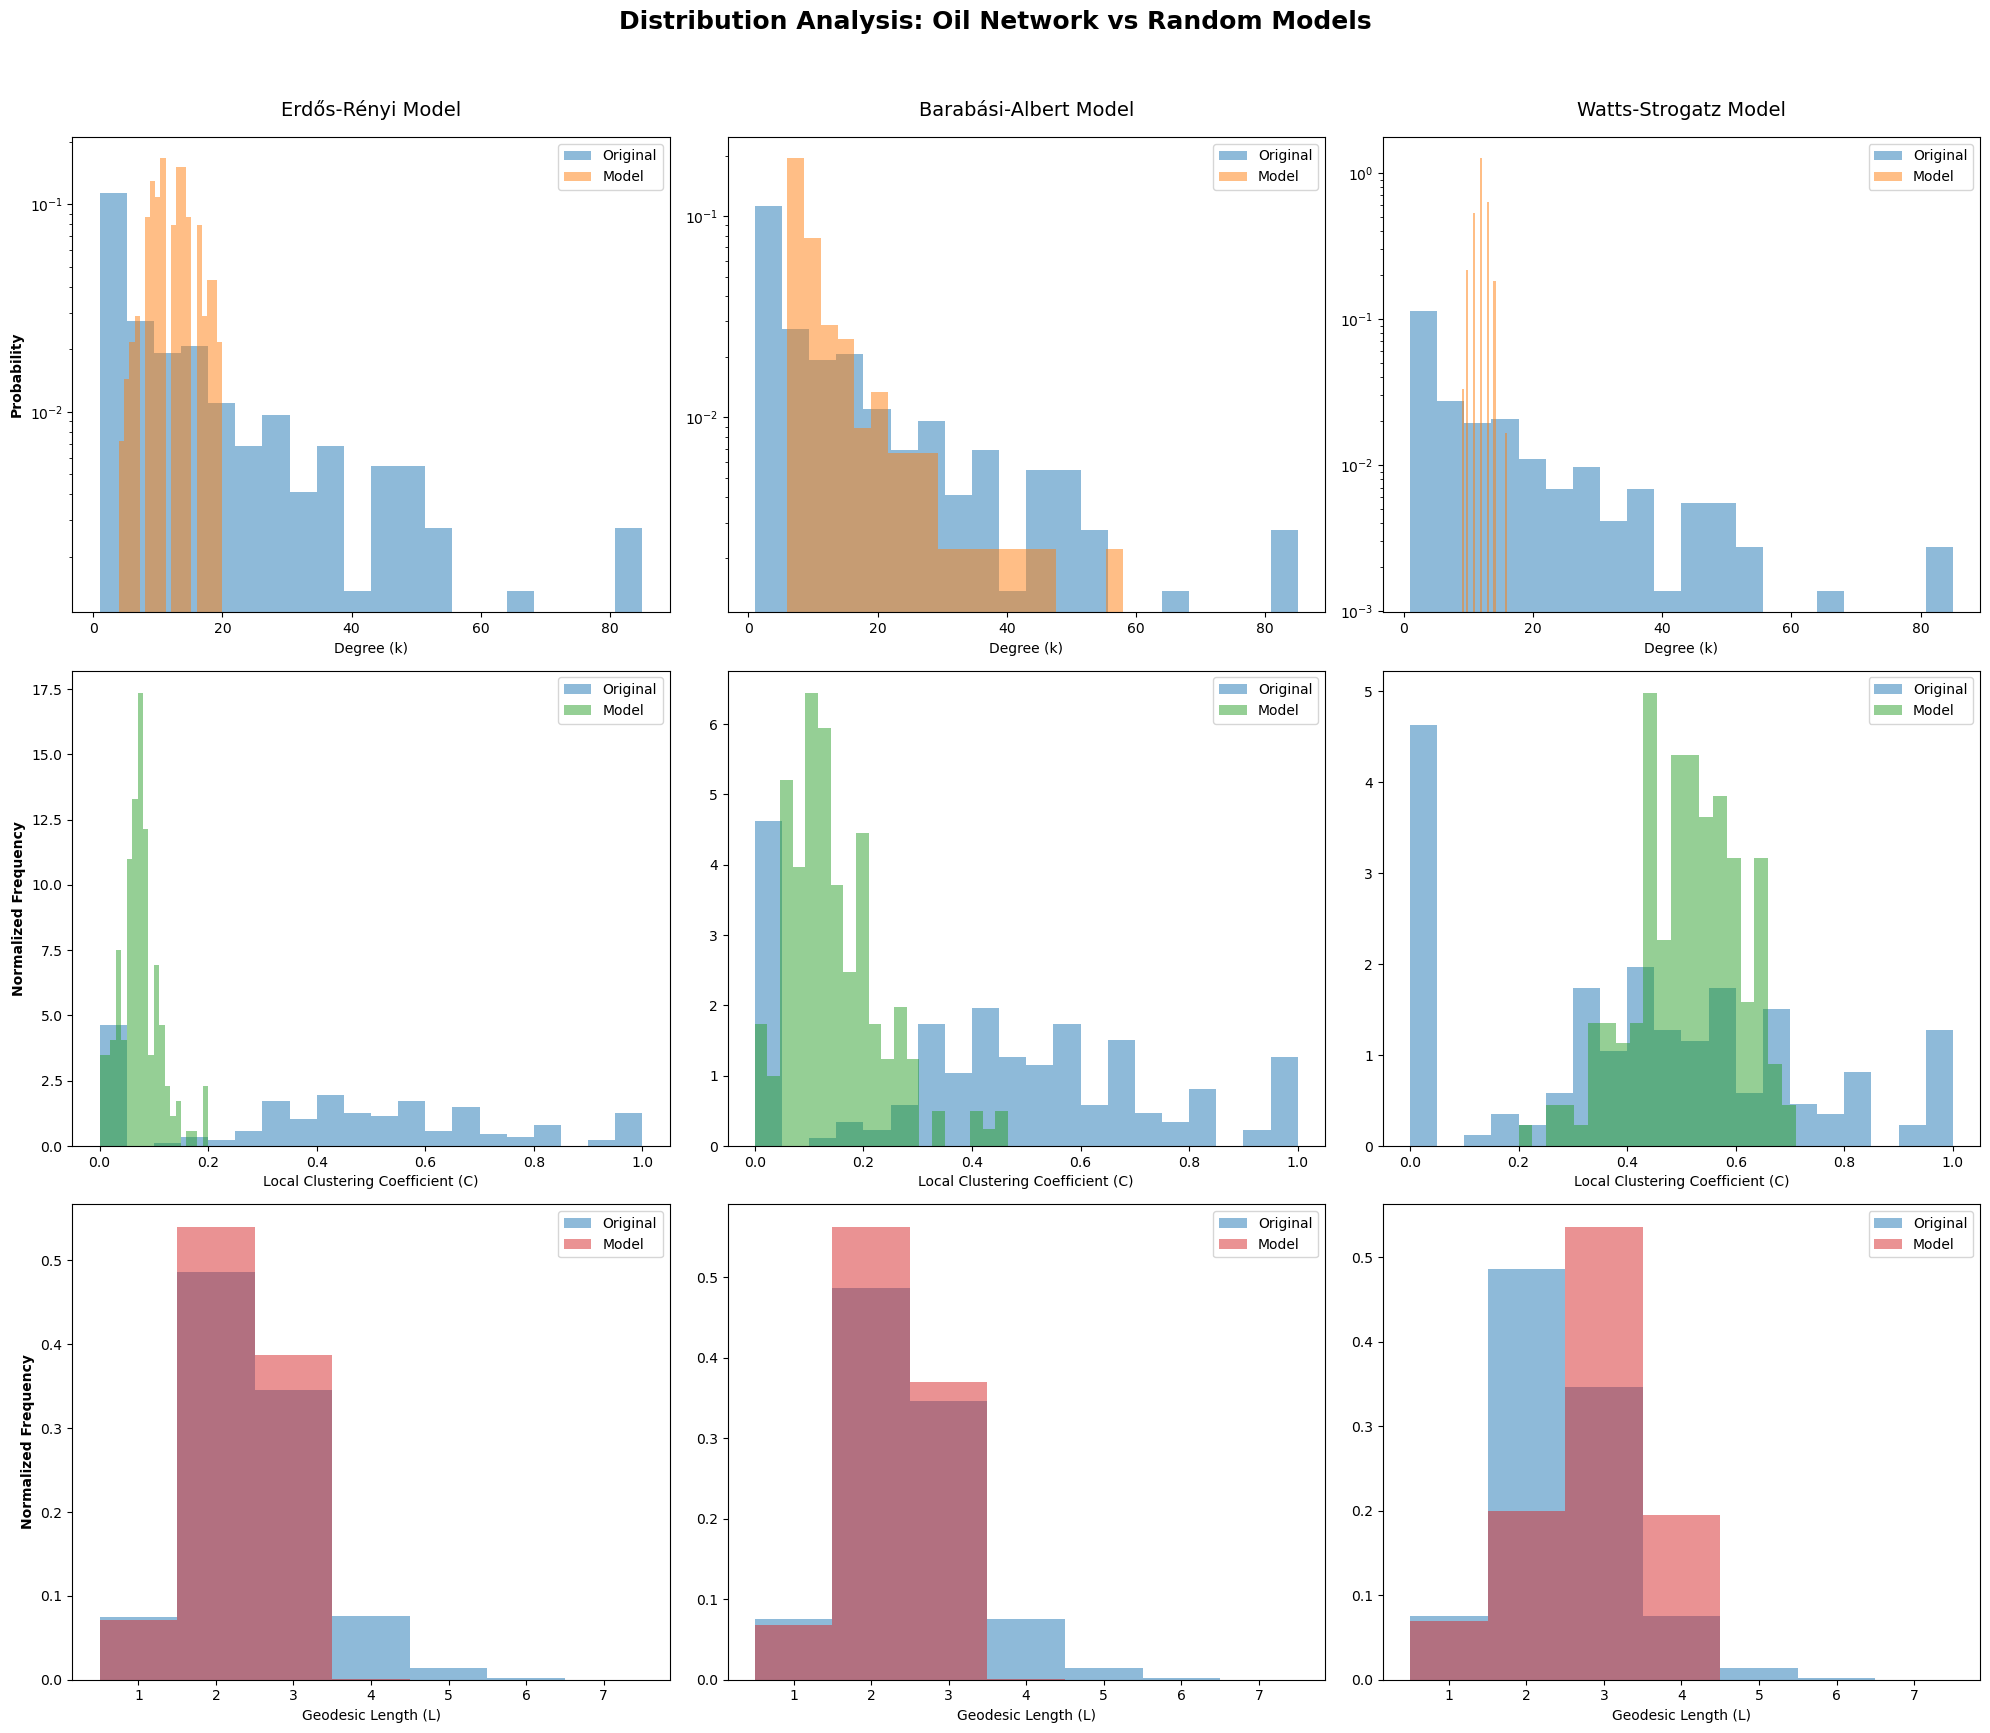

In [ ]:
# 5.1) Auxiliary functions to extract all metrics in list form:
def get_degrees(G):
    return list(dict(G.degree()).values())

def get_clusterings(G):
    return list(nx.clustering(G).values())

def get_path_lengths(G):
    # Extracts all distances between all pairs of nodes (excluding the distance to itself):
    lengths = []
    for source, paths in nx.all_pairs_shortest_path_length(G):
        lengths.extend([l for target, l in paths.items() if source != target])
    return lengths

# 5.2) Extract these metrics from the real graph:
deg_real = get_degrees(graph)
clus_real = get_clusterings(graph)
path_real = get_path_lengths(graph)

# 5.3) Pair the random models in a list to iterate over the columns:
models = [
    ("Erdős-Rényi Model", G_er),
    ("Barabási-Albert Model", G_ba),
    ("Watts-Strogatz Model", G_ws)
    
]

# 5.4) Create the matrix of subplots 3x3 (each row a distinct metric 
# and each column a distinct random graph, comparing them with the original one):
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))
fig.suptitle("Distribution Analysis: Oil Network vs Random Models", fontsize=18, fontweight='bold', y=0.96)

# 5.5) Define the loop which goes through each model and fill in its corresponding column:
for col, (name_model, random_graph) in enumerate(models):
    
    # Extract the metrics from the respective model:
    deg_rand = get_degrees(random_graph)
    clus_rand = get_clusterings(random_graph)
    path_rand = get_path_lengths(random_graph)
    
    # ROW 0 - DEGREE DISTRIBUTION:
    axes[0, col].hist(deg_real, bins=20, alpha=0.5, density=True, label='Original', color='#1f77b4')
    axes[0, col].hist(deg_rand, bins=20, alpha=0.5, density=True, label='Model', color='#ff7f0e')
    axes[0, col].set_title(name_model, fontsize=14, pad=15)

    if col == 0: 
        axes[0, col].set_ylabel('Probability', fontweight='bold')

    axes[0, col].set_xlabel('Degree (k)')
    axes[0, col].set_yscale('log')
    axes[0, col].legend()
    
    # ROW 1 - CLUSTERING DISTRIBUTION:
    axes[1, col].hist(clus_real, bins=20, alpha=0.5, density=True, label='Original', color='#1f77b4')
    axes[1, col].hist(clus_rand, bins=20, alpha=0.5, density=True, label='Model', color='#2ca02c')

    if col == 0: 
        axes[1, col].set_ylabel('Normalized Frequency', fontweight='bold')

    axes[1, col].set_xlabel('Local Clustering Coefficient (C)')
    axes[1, col].legend()
    
    # ROW 2 - GEODETIC PATHS LENGTH DISTRIBUTION:
    bins_path = range(1, max(max(path_real), max(path_rand)) + 2)

    axes[2, col].hist(path_real, bins=bins_path, alpha=0.5, density=True, align='left', label='Original', color='#1f77b4')
    axes[2, col].hist(path_rand, bins=bins_path, alpha=0.5, density=True, align='left', label='Model', color='#d62728')
    
    if col == 0: 
        axes[2, col].set_ylabel('Normalized Frequency', fontweight='bold')

    axes[2, col].set_xlabel('Geodetic Length (L)')
    axes[2, col].legend()

# Adjust spaces and show:
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()